# KAN Activation Functions Comparison

Compare three KAN activation variants on Fashion-MNIST:
- **B-Spline** - Original KAN using B-spline basis
- **RBF** - Radial Basis Functions (Gaussian kernels)
- **Wavelet** - Mexican Hat or Morlet wavelets

Architectures tested:
- **Small Conv** - Lightweight convolutional model
- **Medium MLP** - Standard conv + KAN-based MLP

In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [6]:
from utils import get_fashion_mnist, build_model, count_parameters
from trainer import Trainer
from configs import EXPERIMENTS

In [7]:
# Setup
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


In [8]:
TRAINING = {
    'batch_size': 128,
    'epochs': 15,
    'lr': 1e-3,
    'weight_decay': 1e-5,
}

## 1. Load Data

In [10]:
train_loader, test_loader = get_fashion_mnist(
    batch_size=TRAINING['batch_size'],
    n_train=20000,
    n_test=2000
)

Loaded Fashion-MNIST with 20000 training samples and 2000 test samples.


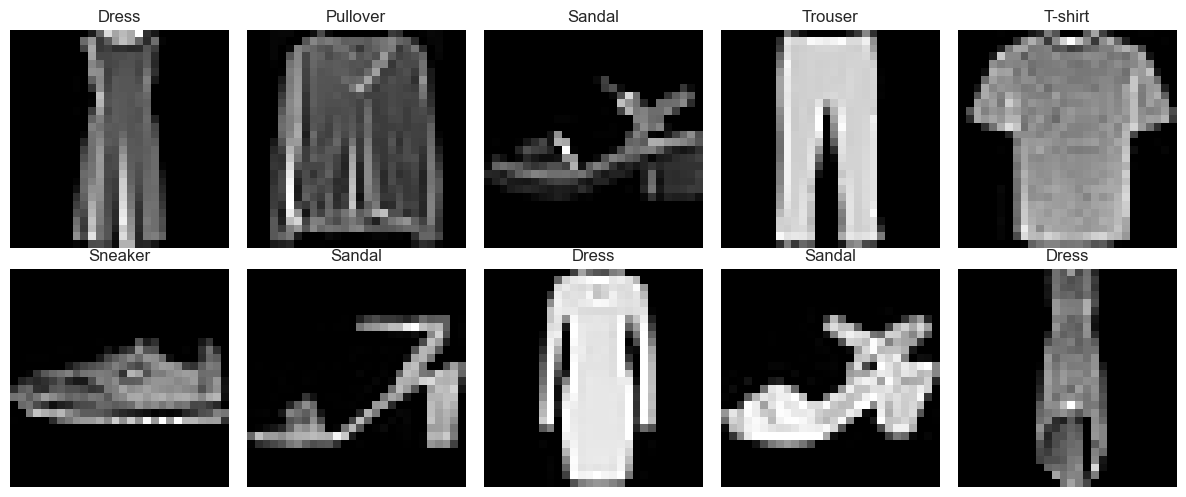

In [11]:
# Visualize samples
classes = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label = train_loader.dataset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(classes[label])
    ax.axis('off')
plt.tight_layout()
plt.show()

## 2. Visualize Activation Functions

In [12]:
from models.KANLinear import KANLinear
from models.RBFLinear import RBFLinear
from models.WavLinear import WavLinear
from configs import BSPLINE, RBF, WAVELET

In [13]:
# Sample input
x = torch.linspace(-2, 2, 1000).unsqueeze(0).unsqueeze(-1)

# Create layers
bspline = KANLinear(1, 1, **BSPLINE)
rbf = RBFLinear(1, 1, **RBF)
wavelet = WavLinear(1, 1, **WAVELET)

# Compute outputs
with torch.no_grad():
    y_bspline = bspline(x).squeeze()
    y_rbf = rbf(x).squeeze()
    y_wavelet = wavelet(x).squeeze()

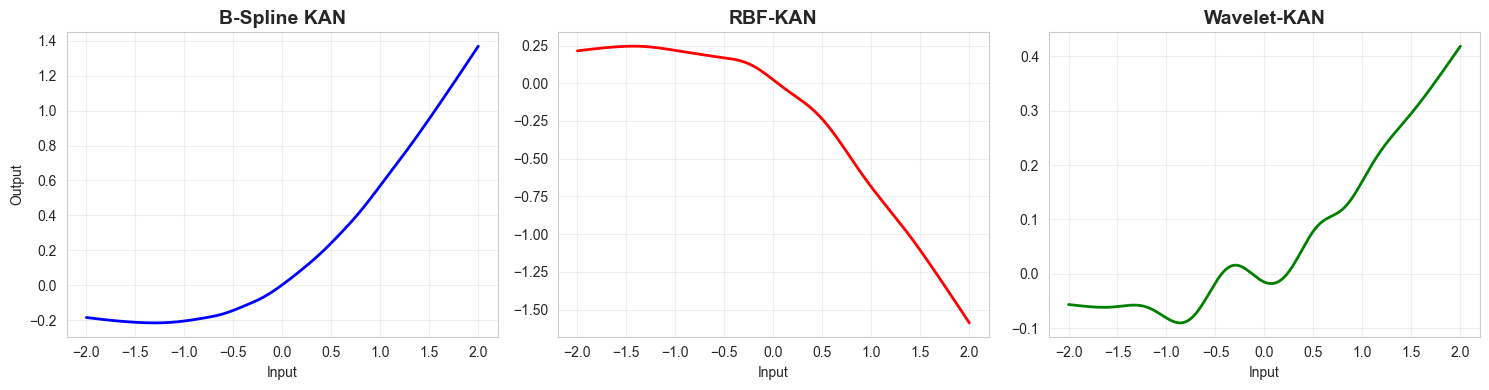

In [14]:
# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x_np = x.squeeze().numpy()

axes[0].plot(x_np, y_bspline.numpy(), 'b-', linewidth=2)
axes[0].set_title('B-Spline KAN', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Input')
axes[0].set_ylabel('Output')
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_np, y_rbf.numpy(), 'r-', linewidth=2)
axes[1].set_title('RBF-KAN', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Input')
axes[1].grid(True, alpha=0.3)

axes[2].plot(x_np, y_wavelet.numpy(), 'g-', linewidth=2)
axes[2].set_title('Wavelet-KAN', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Input')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Run Experiments

Train all model variants and collect results.

In [ ]:
# Select experiments to run (modify as needed)
experiments_to_run = ['small_bspline', 'small_rbf', 'small_wavelet', 'medium_bspline', 'medium_rbf', 'medium_wavelet']

results = {}

for exp_name in experiments_to_run:
    exp_config = EXPERIMENTS[exp_name]
    
    print(f"\n{'='*60}")
    print(f"Experiment: {exp_config['name']}")
    print(f"{'='*60}")
    
    # Build model
    model = build_model(
        architecture=exp_config['architecture'],
        activation=exp_config['activation'],
        config=exp_config['config']
    )
    print(f"Parameters: {count_parameters(model):,}")
    
    # Create trainer
    trainer = Trainer(
        model=model,
        device=device,
        lr=TRAINING['lr'],
        weight_decay=TRAINING['weight_decay'],
        reg_lambda=0.0,
        epochs=TRAINING['epochs']
    )
    
    # Train
    history = trainer.fit(
        train_loader=train_loader,
        val_loader=test_loader,
        epochs=TRAINING['epochs'],
        verbose=True
    )
    
    # Store results
    results[exp_name] = {
        'config': exp_config,
        'history': history,
        'metrics': trainer.get_final_metrics(),
        'num_params': count_parameters(model)
    }
    
    # Save checkpoint
    torch.save({
        'model_state_dict': model.state_dict(),
        'config': exp_config,
        'history': history,
    }, f'./results/{exp_name}_gs=10.pt') # change the grid size in filename if modified

print("\n✓ All experiments completed!")


Experiment: KKAN Small - B-Spline
Parameters: 22,800


Epoch 1/15 | Time: 559.16s | Train Loss: 1.1864 | Train Acc: 64.33% | Val Acc: 74.00% | F1: 0.7316


Epoch 2/15 | Time: 561.88s | Train Loss: 0.5824 | Train Acc: 78.61% | Val Acc: 78.00% | F1: 0.7755


Epoch 3/15 | Time: 563.96s | Train Loss: 0.4893 | Train Acc: 82.00% | Val Acc: 80.50% | F1: 0.8005


Epoch 4/15 | Time: 724.95s | Train Loss: 0.4434 | Train Acc: 83.72% | Val Acc: 82.35% | F1: 0.8188


...

Epoch 11/15 | Time: 433.34s | Train Loss: 0.2953 | Train Acc: 89.70% | Val Acc: 86.00% | F1: 0.8593


Epoch 12/15 | Time: 554.09s | Train Loss: 0.2901 | Train Acc: 89.83% | Val Acc: 86.20% | F1: 0.8612


Epoch 13/15 | Time: 556.89s | Train Loss: 0.2861 | Train Acc: 90.08% | Val Acc: 86.40% | F1: 0.8626


Epoch 14/15 | Time: 548.56s | Train Loss: 0.2837 | Train Acc: 90.05% | Val Acc: 86.65% | F1: 0.8654


Epoch 15/15 | Time: 544.21s | Train Loss: 0.2827 | Train Acc: 90.13% | Val Acc: 86.25% | F1: 0.8616

✓ All experiments completed!


## 4. Visualize Results

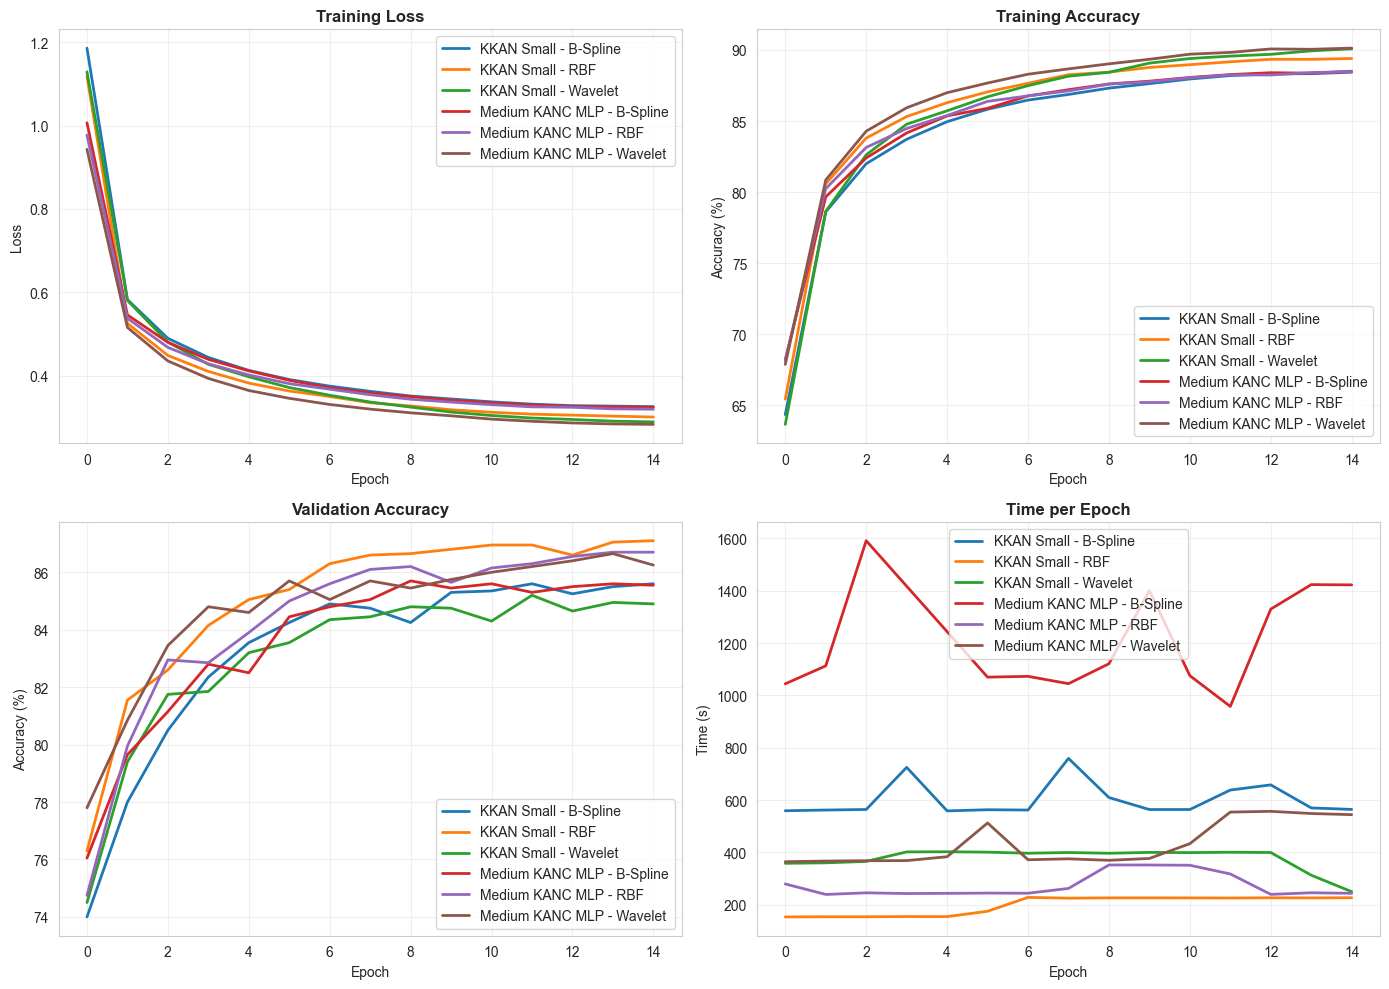

In [54]:
# Training curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for exp_name, result in results.items():
    history = result['history']
    label = result['config']['name']
    
    axes[0, 0].plot(history['train_loss'], label=label, linewidth=2)
    axes[0, 1].plot(history['train_acc'], label=label, linewidth=2)
    axes[1, 0].plot(history['val_acc'], label=label, linewidth=2)
    axes[1, 1].plot(history['epoch_time'], label=label, linewidth=2)

axes[0, 0].set_title('Training Loss', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].set_title('Training Accuracy', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].set_title('Validation Accuracy', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy (%)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].set_title('Time per Epoch', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Time (s)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./results/training_curves_gs=10.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Summary Table

In [51]:
import pandas as pd

summary_data = []
for exp_name, result in results.items():
    metrics = result['metrics']
    summary_data.append({
        'Model': result['config']['name'],
        'Activation': result['config']['activation'].upper(),
        'Parameters': f"{result['num_params']:,}",
        'Accuracy (%)': f"{metrics['accuracy']:.2f}",
        'F1-Score': f"{metrics['f1']:.4f}",
        'Precision': f"{metrics['precision']:.4f}",
        'Recall': f"{metrics['recall']:.4f}",
        'Time/Epoch (s)': f"{metrics['avg_epoch_time']:.2f}"
    })

df = pd.DataFrame(summary_data)
print("\n" + "="*100)
print("RESULTS SUMMARY")
print("="*100)
print(df.to_string(index=False))
print("="*100)

# Save to CSV
df.to_csv('./results/summary_gs=10.csv', index=False)
print("\n✓ Summary saved to results/summary_gs=10.csv")


RESULTS SUMMARY
                     Model Activation Parameters Accuracy (%) F1-Score Precision Recall Time/Epoch (s)
     KKAN Small - B-Spline     SPLINE     22,800        85.60   0.8546    0.8545 0.8560         601.35
          KKAN Small - RBF        RBF     22,190        87.10   0.8698    0.8698 0.8710         198.88
      KKAN Small - Wavelet    WAVELET     26,140        84.90   0.8477    0.8480 0.8490         376.30
Medium KANC MLP - B-Spline     SPLINE      9,935        85.55   0.8545    0.8548 0.8555        1221.68
     Medium KANC MLP - RBF        RBF     13,400        86.70   0.8663    0.8668 0.8670         273.53
 Medium KANC MLP - Wavelet    WAVELET     18,350        86.25   0.8616    0.8616 0.8625         433.01

✓ Summary saved to results/summary_gs=10.csv


## 6. Compare Activations

Direct comparison between activation types.

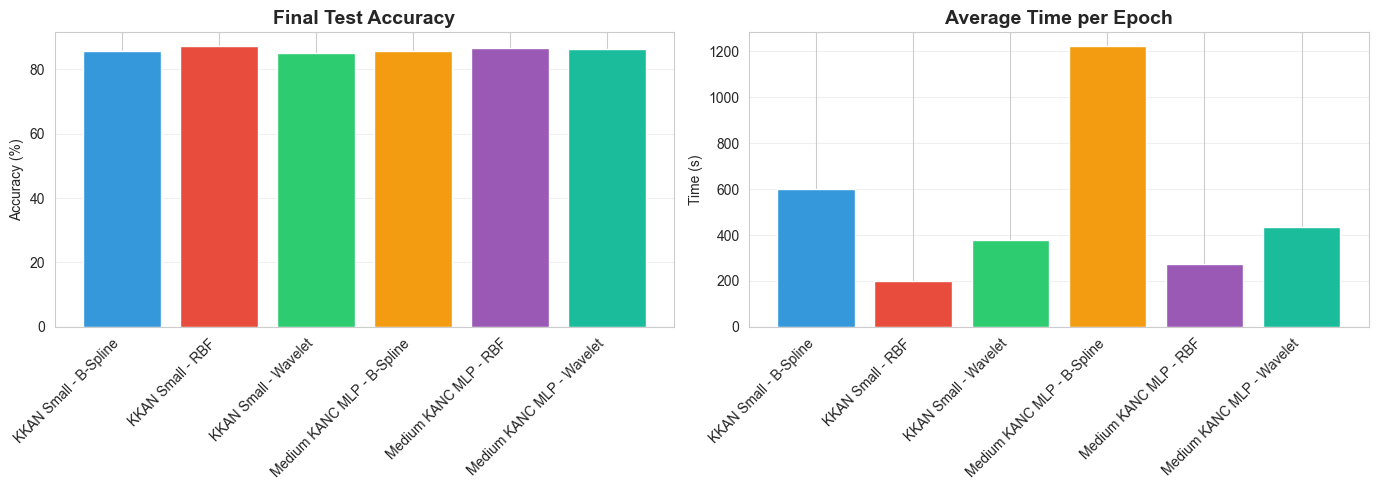

In [52]:
# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = [r['config']['name'] for r in results.values()]
accuracies = [r['metrics']['accuracy'] for r in results.values()]
times = [r['metrics']['avg_epoch_time'] for r in results.values()]

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

axes[0].bar(range(len(models)), accuracies, color=colors[:len(models)])
axes[0].set_xticks(range(len(models)))
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Final Test Accuracy', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(range(len(models)), times, color=colors[:len(models)])
axes[1].set_xticks(range(len(models)))
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].set_ylabel('Time (s)')
axes[1].set_title('Average Time per Epoch', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('./results/comparison_gs=10.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Export Results

Save all results for later analysis.

In [53]:
import json

# Prepare export data
export_data = {}
for exp_name, result in results.items():
    export_data[exp_name] = {
        'name': result['config']['name'],
        'architecture': result['config']['architecture'],
        'activation': result['config']['activation'],
        'parameters': result['num_params'],
        'final_metrics': result['metrics'],
        'history': {
            'train_loss': [float(x) for x in result['history']['train_loss']],
            'train_acc': [float(x) for x in result['history']['train_acc']],
            'val_acc': [float(x) for x in result['history']['val_acc']],
            'val_f1': [float(x) for x in result['history']['val_f1']],
        }
    }

# Save JSON
with open('./results/all_results_gs=10.json', 'w') as f:
    json.dump(export_data, f, indent=2)

print("✓ Results exported to results/all_results_gs=10.json")

✓ Results exported to results/all_results_gs=10.json
